RandomForestClassifier: a custom built class implementation for the randrom forest classifier logic.

src.shared imports: \
numpy as np \
pandas as pd \
matplotlib.pyplot as plt \
utils like load_dataset, calculating metrics, etc.

In [1]:
import sys
from pathlib import Path

project_root = str(Path.cwd().parents[1])

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.classification.random_forest import RandomForestClassifier
from src.shared import *

I chose a dataset suitable for classification. \
What dataset can better demonstrate a random forest classifier, better than a forest dataset? ;)

In [2]:
# --- 1. Load Data ---
df = load_dataset('forest_cover')


# --- 2. Data Cleaning ---
df = clean_dataframe(df)

print(df.columns, '\n')


# --- 3. Analysis ---
print("Statistics:")
print(df.describe())

# Average measurements per forest type
moons_stats = df.groupby('cover_type').mean()

print("\nAverage measurements per forest type:\n")
print(moons_stats)

correlations = df.corr()['cover_type'].sort_values(ascending=False).drop('cover_type')
print("\n\nA table of features correlations with cover type:")
print(correlations)

Index(['elevation', 'aspect', 'slope', 'horizontal_distance_to_hydrology',
       'vertical_distance_to_hydrology', 'horizontal_distance_to_roadways',
       'hillshade_9am', 'hillshade_noon', 'hillshade_3pm',
       'horizontal_distance_to_fire_points', 'wilderness_area1',
       'wilderness_area2', 'wilderness_area3', 'wilderness_area4',
       'soil_type1', 'soil_type2', 'soil_type3', 'soil_type4', 'soil_type5',
       'soil_type6', 'soil_type7', 'soil_type8', 'soil_type9', 'soil_type10',
       'soil_type11', 'soil_type12', 'soil_type13', 'soil_type14',
       'soil_type15', 'soil_type16', 'soil_type17', 'soil_type18',
       'soil_type19', 'soil_type20', 'soil_type21', 'soil_type22',
       'soil_type23', 'soil_type24', 'soil_type25', 'soil_type26',
       'soil_type27', 'soil_type28', 'soil_type29', 'soil_type30',
       'soil_type31', 'soil_type32', 'soil_type33', 'soil_type34',
       'soil_type35', 'soil_type36', 'soil_type37', 'soil_type38',
       'soil_type39', 'soil_type40

In [3]:
# --- 1. Select Features & Target ---
X = df.drop('cover_type', axis=1).values
y = df['cover_type'].values


# --- 2. Split Data for training & testing ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state=None)


# --- 3. Training ---
print(f"Training on {len(X_train)} samples")

model = RandomForestClassifier(max_depth=10, n_trees=5)
model.fit(X_train, y_train)


# --- 4. Evaluation ---
print(f"Testing on {len(X_test)} samples")

predictions = model.predict(X_test)

print("\n--- Testing Results ---")

accuracy = Metrics.accuracy(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")


Training on 58102 samples
Testing on 522910 samples

--- Testing Results ---
Accuracy: 77.92%


This is taking a LOT of time. \
It's like this because this is pure python. \
Since it's taking so much time to train with scratch implementation, I will add a screenshot of a proper random forest classifier, \
made with Scikit-Learn (Cython, much faster).

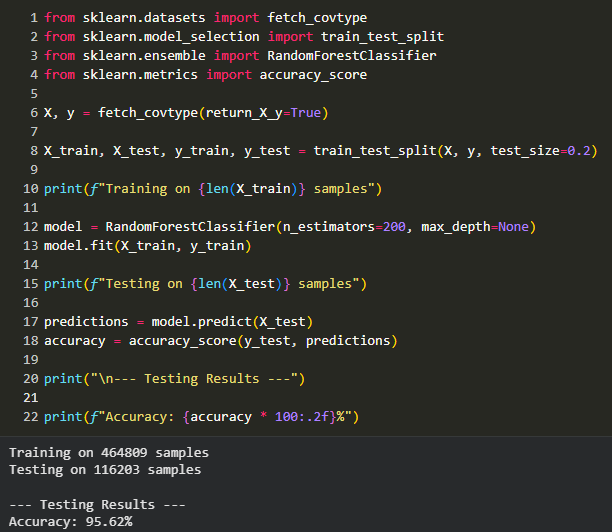

As you can see, the potential is great. The dataset is huge and we can really use the Random Forest Classifier model to it's full potential!